<a href="https://colab.research.google.com/github/letter-b/lab-eda-bivariate/blob/main/LAB_eda_bivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

100%|██████████| 117M/117M [00:01<00:00, 112MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/asaniczka/uk-optimal-product-price-prediction/versions/3


In [2]:
import pandas as pd

amazon_uk = pd.read_csv(path + "/amz_uk_price_prediction_dataset.csv")
amazon_uk.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [3]:
#1.1
crosstab = pd.crosstab(amazon_uk['category'], amazon_uk['isBestSeller'])
print(crosstab.head(10))

isBestSeller                       False  True 
category                                       
3D Printers                          247      1
3D Printing & Scanning              4065      2
Abrasive & Finishing Products        245      5
Action Cameras                      1696      1
Adapters                             251      3
Agricultural Equipment & Supplies   8421    109
Alexa Built-In Devices               106      1
Art & Craft Supplies                 253      5
Arts & Crafts                       9319    230
Baby                               14709    341


In [4]:
#adding proportions/percentages
crosstab_pct = pd.crosstab(
    amazon_uk['category'],
    amazon_uk['isBestSeller'],
    normalize='index'  # normalise across each row (category)
).round(4) * 100

print(crosstab_pct.head(10))

isBestSeller                       False  True 
category                                       
3D Printers                        99.60   0.40
3D Printing & Scanning             99.95   0.05
Abrasive & Finishing Products      98.00   2.00
Action Cameras                     99.94   0.06
Adapters                           98.82   1.18
Agricultural Equipment & Supplies  98.72   1.28
Alexa Built-In Devices             99.07   0.93
Art & Craft Supplies               98.06   1.94
Arts & Crafts                      97.59   2.41
Baby                               97.73   2.27


In [5]:
#adding a rank
crosstab_pct_sorted = crosstab_pct.sort_values(by=True, ascending=False)
print(crosstab_pct_sorted.head(10))

isBestSeller                    False  True 
category                                    
Grocery                         94.19   5.81
Smart Home Security & Lighting  94.23   5.77
Health & Personal Care          94.23   5.77
Mobile Phone Accessories        95.75   4.25
Power & Hand Tools              96.47   3.53
Billiard, Snooker & Pool        96.79   3.21
Pet Supplies                    96.98   3.02
Home Brewing & Wine Making      97.15   2.85
Mirrors                         97.20   2.80
Wind Instruments                97.20   2.80


In [6]:
#1.2

# Step 1 — building raw counts crosstab as chi-square needs counts, not percentages
crosstab = pd.crosstab(amazon_uk['category'], amazon_uk['isBestSeller'])

# Step 2 —  chi-square test
chi2, p_value, dof, expected = chi2_contingency(crosstab)

In [7]:
# Step 3 — calculate Cramér's V
n = crosstab.sum().sum()          # total number of observations
min_dim = min(crosstab.shape) - 1 # smaller of (rows-1, cols-1)
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Chi-square: {chi2:,.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p_value:.10f}")
print(f"Cramér's V:           {cramers_v:.4f}")

Chi-square: 36,540.20
Degrees of freedom:   295
P-value:              0.0000000000
Cramér's V:           0.1223


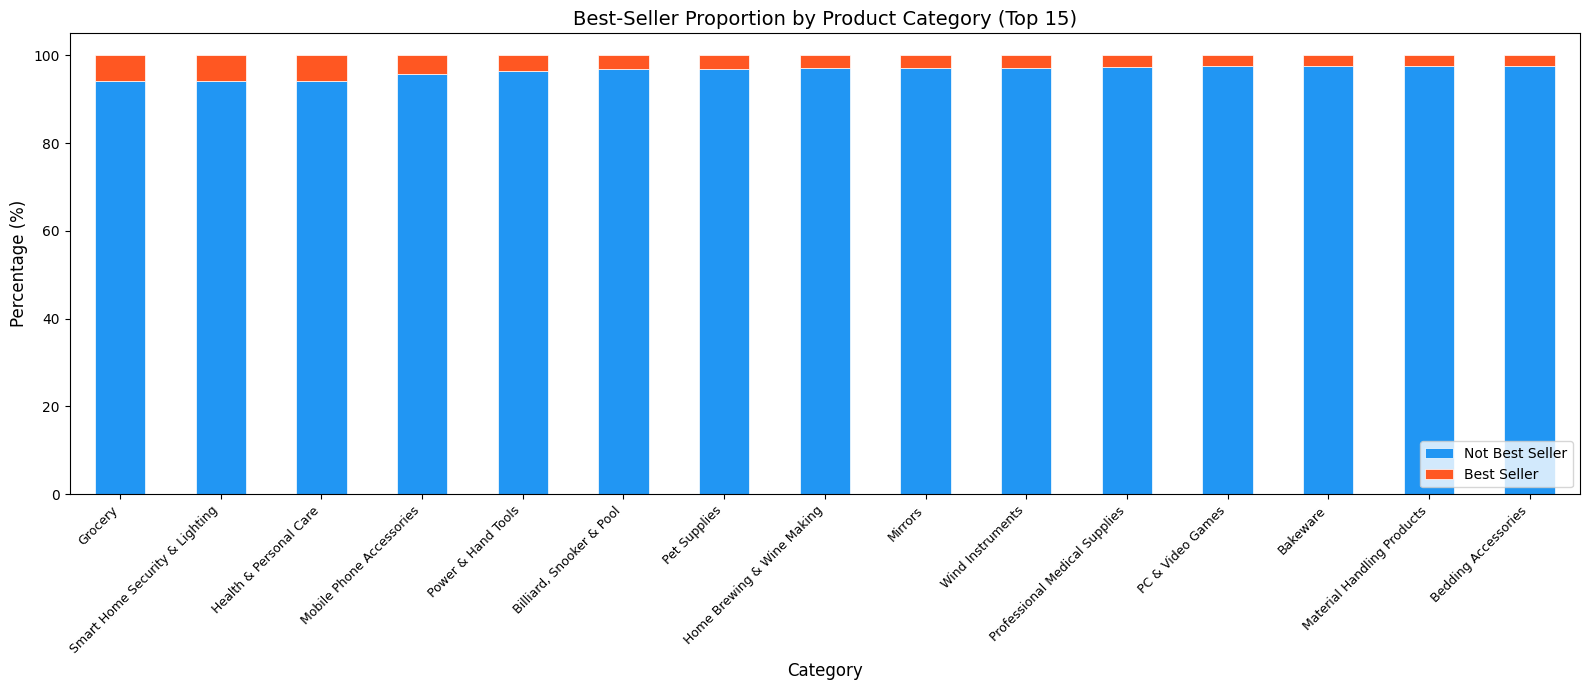

In [8]:
# Proportions
crosstab_pct = pd.crosstab(
    amazon_uk['category'],
    amazon_uk['isBestSeller'],
    normalize='index'
) * 100

# Sort by best-seller proportion descending
crosstab_pct = crosstab_pct.sort_values(by=True, ascending=False)

# Top 20 categories for readability
top20 = crosstab_pct.head(15)

top20.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 7),
    color=['#2196F3', '#FF5722'],
    edgecolor='white',
    linewidth=0.5
)

plt.title('Best-Seller Proportion by Product Category (Top 15)', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.legend(['Not Best Seller', 'Best Seller'], loc='lower right')
plt.tight_layout()
plt.show()

In [9]:
#2.0
# Step 1 — calculating fences
Q1  = amazon_uk['price'].quantile(0.25)
Q3  = amazon_uk['price'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Q1:            £{Q1:.2f}")
print(f"Q3:            £{Q3:.2f}")
print(f"IQR:           £{IQR:.2f}")
print(f"Lower fence:   £{lower_fence:.2f}")
print(f"Upper fence:   £{upper_fence:.2f}")

# Step 2 — filter the dataframe
amazon_uk_clean = amazon_uk[
    (amazon_uk['price'] >= lower_fence) &
    (amazon_uk['price'] <= upper_fence)
]

# Step 3 — check how many rows were removed
removed = len(amazon_uk) - len(amazon_uk_clean)
pct_removed = removed / len(amazon_uk) * 100

print(f"\nOriginal rows:  {len(amazon_uk):,}")
print(f"Cleaned rows:   {len(amazon_uk_clean):,}")
print(f"Rows removed:   {removed:,} ({pct_removed:.2f}%)")

Q1:            £9.99
Q3:            £45.99
IQR:           £36.00
Lower fence:   £-44.01
Upper fence:   £99.99

Original rows:  2,443,651
Cleaned rows:   2,115,963
Rows removed:   327,688 (13.41%)


/tmp/ipykernel_2324/2295837476.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


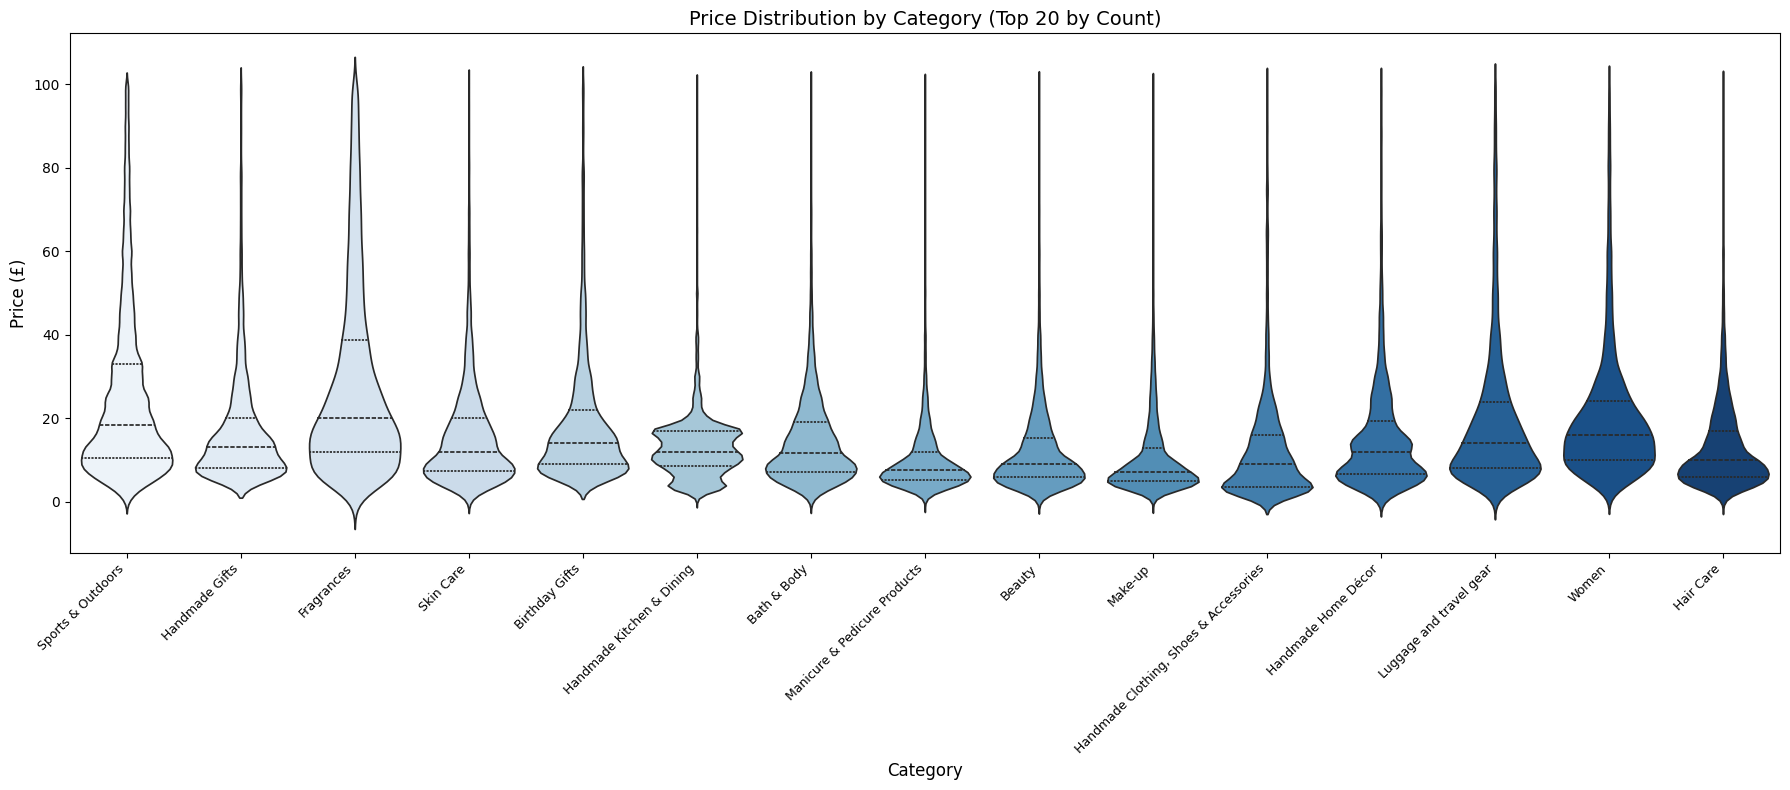

In [11]:
#2.1.
import seaborn as sns

# Get top 15 categories by listing count
top15_cats = amazon_uk_clean['category'].value_counts().head(15).index

# Filter to only those categories
top15_data = amazon_uk_clean[amazon_uk_clean['category'].isin(top15_cats)]

# Plot
plt.figure(figsize=(18, 8))
sns.violinplot(
    data=top15_data,
    x='category',
    y='price',
    palette='Blues',
    inner='quartile'  # shows Q1, median, Q3 lines inside each violin
)
plt.title('Price Distribution by Category (Top 20 by Count)', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Price (£)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

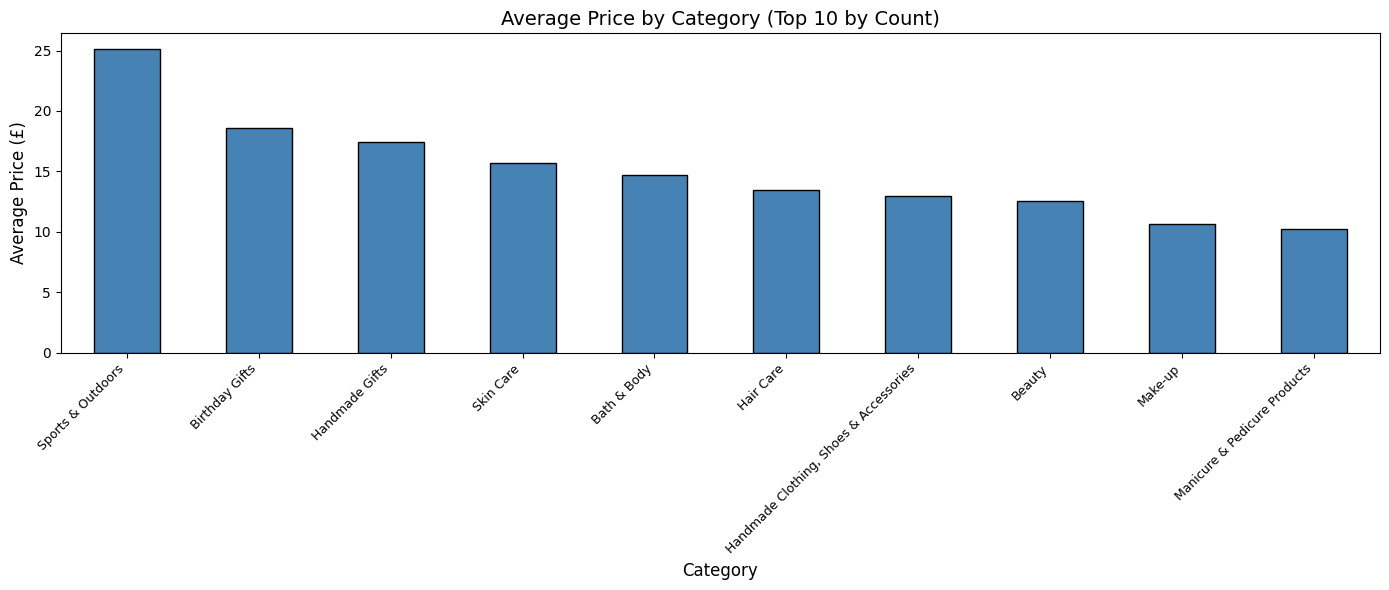

In [12]:
#2.2.
# Get top 10 categories by count
top10_cats = amazon_uk_clean['category'].value_counts().head(10).index

# Calculate average price for those categories
avg_price_top10 = (
    amazon_uk_clean[amazon_uk_clean['category'].isin(top10_cats)]
    .groupby('category')['price']
    .mean()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(14, 6))
avg_price_top10.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Price by Category (Top 10 by Count)', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Price (£)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

Sports and Outdoors seem to have the highest average price.

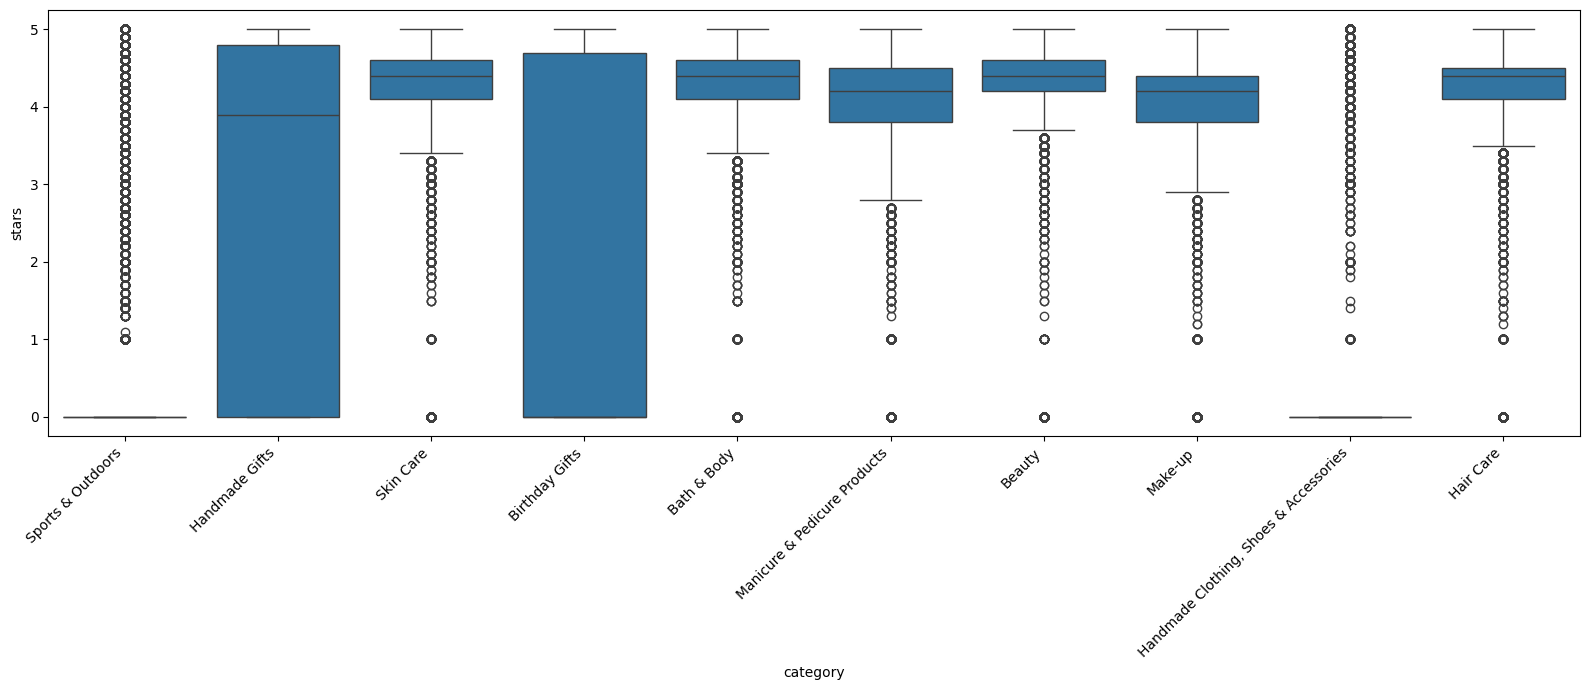

In [23]:
#3.3.1
# Filter to top 10 categories
top10_cats = amazon_uk_clean['category'].value_counts().head(10).index
top10_data = amazon_uk_clean[amazon_uk_clean['category'].isin(top10_cats)]

# Plot
plt.figure(figsize=(16, 7))
sns.boxplot(data=top10_data, x='category', y='stars')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Computer Memory seems to have the highest ratings.



---



In [24]:
#2.3.2
median_rating_by_cat = (
    amazon_uk_clean
    .groupby('category')['stars']
    .median()
    .sort_values(ascending=False)
)

print(median_rating_by_cat.head(10))

category
Computer Memory                 4.7
Beer, Wine & Spirits            4.6
Building & Construction Toys    4.6
Office Paper Products           4.6
Kids' Play Figures              4.6
Laptop Accessories              4.6
Hobbies                         4.6
Luxury Food & Drink             4.6
Soft Toys                       4.5
Boxes & Organisers              4.5
Name: stars, dtype: float64


This perfectly illustrates why we should filter for visualizations but not for calculations. Since these "niche" categories didn't even appear in the box-plot. Volume vs Quality.

In [19]:
#3.1.1
correlation = amazon_uk_clean['price'].corr(amazon_uk_clean['stars'])
print(f"Correlation between price and stars: {correlation:.4f}")

Correlation between price and stars: -0.0777


In [20]:
pearson  = amazon_uk_clean['price'].corr(amazon_uk_clean['stars'], method='pearson')
spearman = amazon_uk_clean['price'].corr(amazon_uk_clean['stars'], method='spearman')

print(f"Pearson correlation:  {pearson:.4f}")
print(f"Spearman correlation: {spearman:.4f}")

Pearson correlation:  -0.0777
Spearman correlation: -0.0668


The relationship between price and ratings on Amazon UK is essentially non-existent.

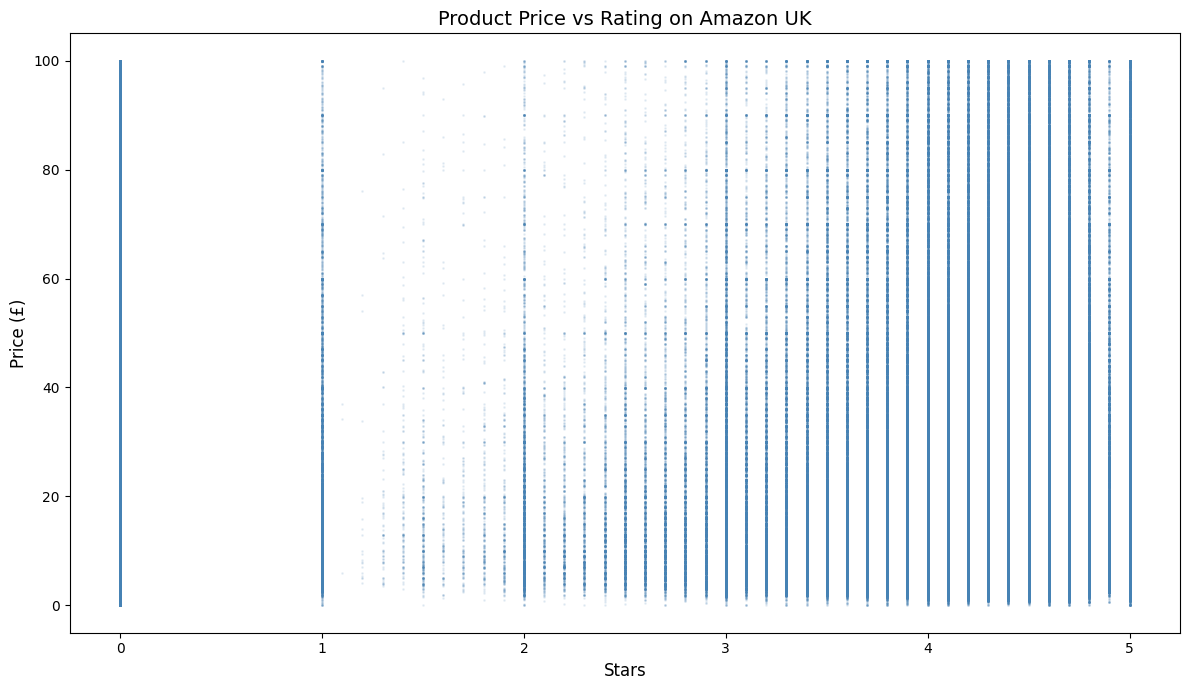

In [29]:
#2.1.1.
plt.figure(figsize=(12, 7))
plt.scatter(
    amazon_uk_clean['stars'],
    amazon_uk_clean['price'],
    alpha=0.1,        # transparency — essential with 2M+ points
    s=1,              # tiny point size — avoids overplotting
    color='steelblue'
)
plt.title('Product Price vs Rating on Amazon UK', fontsize=14)
plt.xlabel('Stars', fontsize=12)
plt.ylabel('Price (£)', fontsize=12)
plt.tight_layout()
plt.show()

Observations:

1.   A lot of "0" which are essentially no reviews and not real "0" of dissatisfaction.
2.   Lines get denser between 4-5* which confirms skewness.
3. No real trend which confirms the correlation number calculated earlier.
4. Customers rate products on their quality more than price.


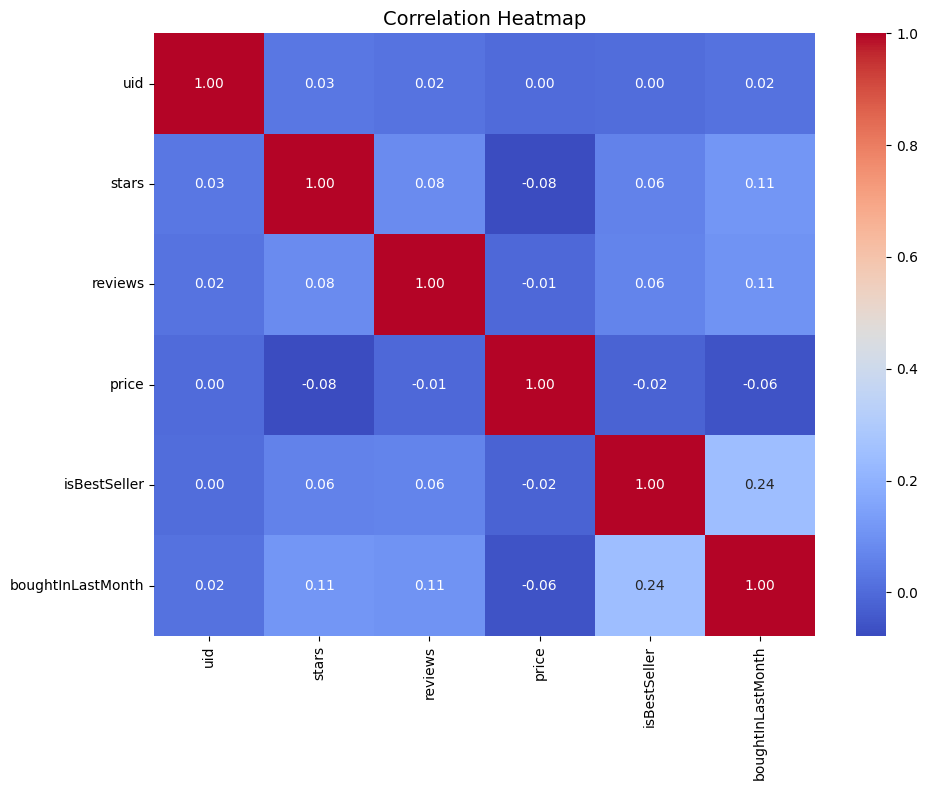

In [30]:
#3.2.2.
plt.figure(figsize=(10, 8))
sns.heatmap(
    amazon_uk_clean.corr(numeric_only=True),
    annot=True,      # shows the numbers inside each square
    fmt='.2f',       # 2 decimal places
    cmap='coolwarm'  # blue = negative, red = positive
)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()



*  isBestSeller vs boughtInLastMonth (0.24)
The strongest relationship in the whole heatmap. Products bought more recently are more likely to be best sellers — makes sense. Still only weak-moderate.
*   Reviews and Boughtlastmonth (0.11)
Products with more reviews tend to be bought more recently — popular products stay popular.
* stars vs boughtInLastMonth (0.11)
Slightly better rated products tend to be bought more — customers do pay some attention to ratings when purchasing.
* stars vs price → -0.08
Confirms earlier finding — essentially no relationship between price and rating.
* price vs boughtInLastMonth (-0.06)
Cheaper products tend to be bought more recently — budget products move faster, which makes sense for Amazon UK.



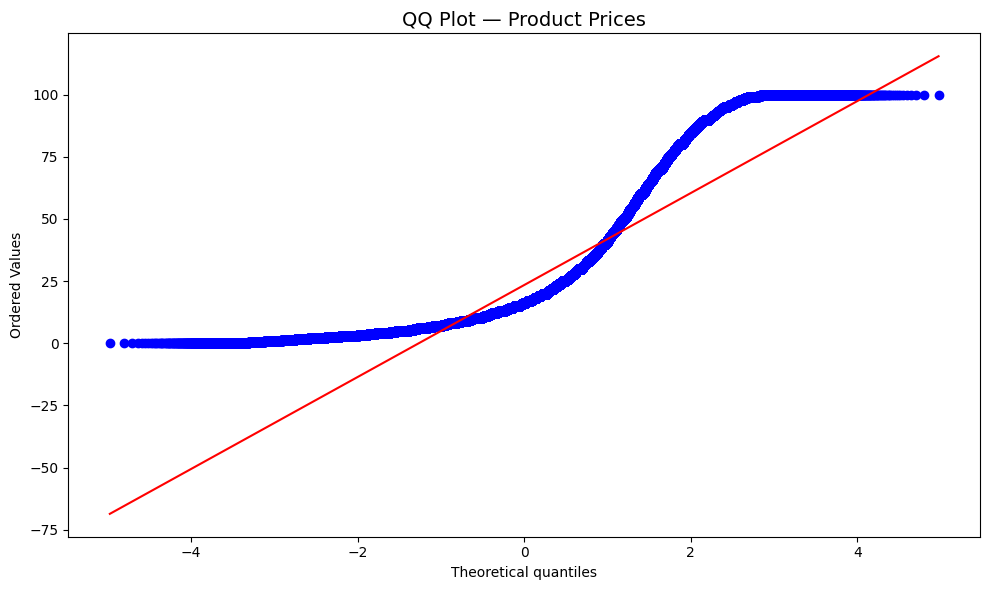

In [31]:
#3.3.3
from scipy import stats

plt.figure(figsize=(10, 6))
stats.probplot(amazon_uk_clean['price'], dist="norm", plot=plt)
plt.title('QQ Plot — Product Prices', fontsize=14)
plt.tight_layout()
plt.show()

This shows that product prices on Amazon UK are not normally distributed — confirming everything found earlier with the skewness, kurtosis, and histogram. The IQR outlier removal actually made the non-normality even more visible.

business-centric report:
Amazon UK is a budget-dominated marketplace. Most products are priced around £19, with £9.99 being the single most common price point. A small number of expensive products inflate the average to £89, but they are the exception rather than the rule.
Customers rate generously and consistently — most products sit between 4.1 and 4.6 stars regardless of price. Crucially, paying more does not mean better reviews. Price and ratings are essentially unrelated, meaning quality matters far more than cost to Amazon UK shoppers.
Niche categories like Computer Memory earn the highest ratings, while high-volume categories like Beauty dominate listings but not necessarily satisfaction. Being in a popular category gives a slight best-seller advantage, but it is no guarantee of success.
In short — on Amazon UK, low prices win traffic and genuine quality wins customers.
